In [6]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    set_seed
)

os.makedirs("artifacts", exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [7]:
# Загружаем рекомендованный датасет (используем dair-ai/emotion, так как оригинальный emotion переехал)
dataset = load_dataset("dair-ai/emotion")

print("Размеры сплитов датасета:")
print(dataset)

class_names = dataset['train'].features['label'].names
num_labels = len(class_names)
print(f"\nКоличество классов: {num_labels}")
print(f"Названия классов: {class_names}")

print("\nПримеры данных (train):")
df_sample = pd.DataFrame(dataset['train'][:5])
df_sample['label_name'] = df_sample['label'].apply(lambda x: class_names[x])
display(df_sample)



Размеры сплитов датасета:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Количество классов: 6
Названия классов: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры данных (train):


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [8]:
MODEL_NAME = "distilbert-base-uncased" # Используем легкую и быструю модель

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = dataset['train']['text'][:3]

print("Разбор токенизации на нескольких примерах:\n")
for i, text in enumerate(sample_texts):
    print(f"--- Текст {i+1} ---")
    print(f"Оригинал: {text}")

    encoded = tokenizer(text, padding="max_length", truncation=True, max_length=15)

    print(f"Токены (строки): {tokenizer.convert_ids_to_tokens(encoded['input_ids'])}")
    print(f"input_ids: {encoded['input_ids']}")
    print(f"attention_mask: {encoded['attention_mask']}\n")



Разбор токенизации на нескольких примерах:

--- Текст 1 ---
Оригинал: i didnt feel humiliated
Токены (строки): ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]

--- Текст 2 ---
Оригинал: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены (строки): ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

--- Текст 3 ---
Оригинал: im grabbing a minute to post i feel greedy wrong
Токены (строки): ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wro

In [9]:
raw_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels).to(device)

print("Инференс не-дообученной модели:\n")
raw_model.eval()
with torch.no_grad():
    for i, text in enumerate(sample_texts):
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
        outputs = raw_model(**inputs)
        logits = outputs.logits
        predicted_class_id = torch.argmax(logits, dim=-1).item()
        print(f"Текст: '{text}'")
        print(f"Случайное предсказание модели: {class_names[predicted_class_id]}")
        print(f"Истинная метка: {class_names[dataset['train']['label'][i]]}\n")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Инференс не-дообученной модели:

Текст: 'i didnt feel humiliated'
Случайное предсказание модели: anger
Истинная метка: sadness

Текст: 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'
Случайное предсказание модели: anger
Истинная метка: sadness

Текст: 'im grabbing a minute to post i feel greedy wrong'
Случайное предсказание модели: anger
Истинная метка: anger



In [11]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": acc, "f1_macro": f1}

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels).to(device)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics # Added compute_metrics
)

print("Запуск fine-tuning...")
trainer.train()

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Запуск fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.641985,0.225095,0.923000,0.897609
2,0.174169,0.171412,0.931000,0.906741


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1000, training_loss=0.40807662963867186, metrics={'train_runtime': 374.965, 'train_samples_per_second': 85.341, 'train_steps_per_second': 2.667, 'total_flos': 1059814785024000.0, 'train_loss': 0.40807662963867186, 'epoch': 2.0})

Оценка на тестовой выборке:


Test Accuracy: 0.9215
Test F1-macro: 0.8757

Файл artifacts/sample_predictions.csv успешно сохранен.


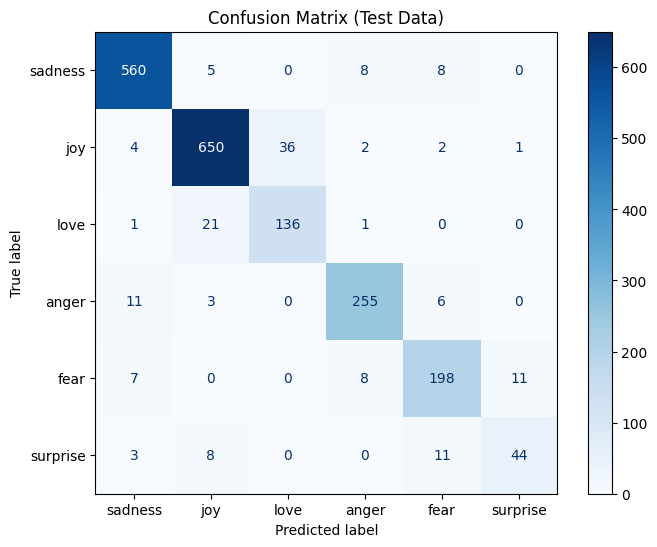

Файл artifacts/confusion_matrix.png успешно сохранен.

--- Примеры ошибок модели ---


,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.670581
67,i feel a bit stressed even though all the thin...,anger,sadness,0.809961
72,i am right handed however i play billiards lef...,surprise,fear,0.625677
86,i feel like i am in paradise kissing those swe...,joy,love,0.696285
93,i was feeling weird the other day and it went ...,fear,surprise,0.555911


In [12]:
print("Оценка на тестовой выборке:")
test_results = trainer.predict(tokenized_datasets["test"])
print(f"Test Accuracy: {test_results.metrics['test_accuracy']:.4f}")
print(f"Test F1-macro: {test_results.metrics['test_f1_macro']:.4f}")

preds = np.argmax(test_results.predictions, axis=-1)
true_labels = tokenized_datasets["test"]["label"]
texts = tokenized_datasets["test"]["text"]

softmax = torch.nn.Softmax(dim=1)
probs = softmax(torch.tensor(test_results.predictions))
confidences = torch.max(probs, dim=1).values.numpy()

pred_df = pd.DataFrame({
    "text": texts,
    "true_label": [class_names[label] for label in true_labels],
    "pred_label": [class_names[pred] for pred in preds],
    "confidence": confidences
})
pred_df.to_csv("artifacts/sample_predictions.csv", index=False)
print("\nФайл artifacts/sample_predictions.csv успешно сохранен.")

cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix (Test Data)")
plt.savefig("artifacts/confusion_matrix.png", bbox_inches='tight')
plt.show()
print("Файл artifacts/confusion_matrix.png успешно сохранен.")

print("\n--- Примеры ошибок модели ---")
errors_df = pred_df[pred_df['true_label'] != pred_df['pred_label']].head(5)
display(errors_df)

